In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet

from prophet_feature_engineering import create_prophet_features

from sklearn.metrics import mean_absolute_error, mean_squared_error

c:\Users\i-tawhidur\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
df = pd.read_csv("../Datasets/new_transaction_data.csv")
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")
df.head()

,date,txn_count,lag_1,lag_7,lag_10,lag_15,lag_30,rolling_7,rolling_10,rolling_15,rolling_30,is_campaign,count_camp,total_txn_current,total_txn_nextday
0,2024-01-01,40548,0.0,0.0,0.0,0.0,0.0,198926195.2,198926195.2,198926195.2,198926195.2,0,0,198926195.2,228402460.0
1,2024-01-02,40302,198926195.2,0.0,0.0,0.0,0.0,213664327.6,213664327.6,213664327.6,213664327.6,0,0,228402460.0,234645002.7
2,2024-01-03,48700,228402460.0,0.0,0.0,0.0,0.0,220657885.9,220657885.9,220657885.9,220657885.9,0,0,234645002.7,374170001.3
3,2024-01-04,60370,234645002.7,0.0,0.0,0.0,0.0,259035914.8,259035914.8,259035914.8,259035914.8,0,0,374170001.3,133723818.4
4,2024-01-05,32176,374170001.3,0.0,0.0,0.0,0.0,233973495.5,233973495.5,233973495.5,233973495.5,0,0,133723818.4,212409811.5


In [40]:
split_ratio = 0.8

split_index = int(len(df) * split_ratio)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (669, 15)
Test: (168, 15)


In [41]:
def prepare_prophet_df(df):

    base = pd.DataFrame()
    base["ds"] = df["date"]
    base["y"] = df["total_txn_current"]

    features = create_prophet_features(df)

    base = pd.concat(
        [base.reset_index(drop=True),
         features.reset_index(drop=True)],
        axis=1
    )

    base = base.fillna(0)

    return base

In [42]:
train_prophet = prepare_prophet_df(train_df)
test_prophet  = prepare_prophet_df(test_df)

In [84]:
regressors = [
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_salary_period",
    "salary_peak",
    "salary_mid",
    "salary_late",
    "is_mid_month",
    "is_end_month_spike",
    "is_payday",
    "weekend_payday",
    "campaign_window",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "dom_sin",
    "dom_cos"
]

# keep only existing columns
regressors = [r for r in regressors if r in train_prophet.columns]

In [85]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10.0
)

for r in regressors:
    model.add_regressor(r)

model.fit(train_prophet)

11:12:05 - cmdstanpy - INFO - Chain [1] start processing
11:12:06 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
future = test_prophet.copy()

# Ensure all regressors exist
for col in regressors:
    if col not in future.columns:
        future[col] = 0

future = future[["ds"] + regressors]

In [87]:
forecast = model.predict(future)

pred_df = forecast[["ds", "yhat"]].copy()
pred_df.rename(columns={"yhat": "y_pred"}, inplace=True)

# merge with actual
actual_df = test_prophet[["ds", "y"]]

final_df = pd.merge(actual_df, pred_df, on="ds")
final_df.head()

,ds,y,y_pred
0,2025-10-31,374889615.9,4.145607e+08
1,2025-11-01,327741104.9,2.207771e+08
2,2025-11-02,387863756.5,3.773719e+08
3,2025-11-03,362664653.0,3.655827e+08
4,2025-11-04,372338035.8,4.338372e+08


In [88]:
y_true = final_df["y"]
y_pred = final_df["y_pred"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 172,168,873.35
RMSE : 214,398,624.60
MAPE : 54.99%


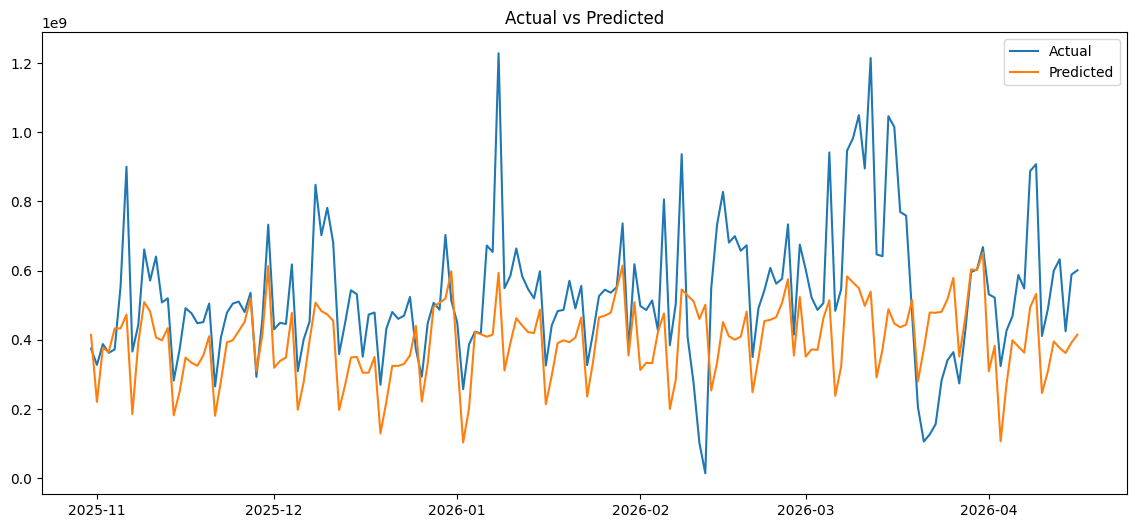

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(final_df["ds"], final_df["y"], label="Actual")
plt.plot(final_df["ds"], final_df["y_pred"], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [83]:
final_df["error"] = final_df["y"] - final_df["y_pred"]
final_df["abs_error"] = np.abs(final_df["error"])

final_df.sort_values("abs_error", ascending=False).head(10)

,ds,y,y_pred,error,abs_error
132,2026-03-12,1.214566e+09,5.392686e+08,6.752971e+08,6.752971e+08
69,2026-01-08,1.228287e+09,5.936360e+08,6.346510e+08,6.346510e+08
136,2026-03-16,1.015107e+09,4.473145e+08,5.677928e+08,5.677928e+08
135,2026-03-15,1.046424e+09,4.888259e+08,5.575977e+08,5.575977e+08
130,2026-03-10,1.049426e+09,5.495458e+08,4.998799e+08,4.998799e+08
104,2026-02-12,1.442466e+07,5.015339e+08,-4.871092e+08,4.871092e+08
6,2025-11-06,9.004658e+08,4.730825e+08,4.273834e+08,4.273834e+08
125,2026-03-05,9.417619e+08,5.144770e+08,4.272849e+08,4.272849e+08
129,2026-03-09,9.824831e+08,5.658304e+08,4.166527e+08,4.166527e+08
106,2026-02-14,7.340530e+08,3.344613e+08,3.995916e+08,3.995916e+08
